In [4]:
import numpy as np
import matplotlib.pyplot as plt

from fenics import *
from pathlib import Path
from utils.colors import C2
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit
from utils.mesh_utils import get_L_mesh, get_donut_mesh

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [5]:

mesh = UnitSquareMesh(16, 16)
V_h = FunctionSpace(mesh, 'CG', 1)
exact = ExactForwardOperator(V_h)
U, S, Vt = np.linalg.svd(exact.K, full_matrices=False)

In [8]:
print("Shape of K:", exact.K.shape)

Shape of K: (64, 289)


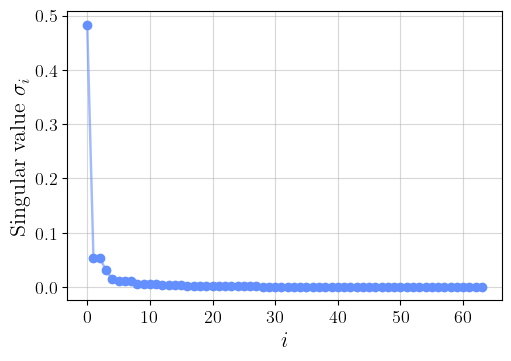

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3.5), constrained_layout=True)

upper = 64

ax.plot(S[:upper], 'o', c=C2[0], ms=6)
ax.plot(S[:upper], '-', c=C2[0], alpha=0.6, lw=1.75)

ax.set_xlabel("$i$", fontsize=16)
ax.set_ylabel("Singular value $\sigma_i$", fontsize=16)
ax.grid(True, alpha=0.5)

path = Path(f"../../figures/singular_values.png")
plt.savefig(path, dpi=300, bbox_inches="tight")
